# Low-Rank Matrix Factorization (AKA Truncated SVD)

### Imports and Environment Variables

In [9]:
import zarr
import scipy.sparse as sp
import numpy as np
from scipy.sparse.linalg import LinearOperator
import time as time
import matplotlib.pyplot as plt

In [7]:
store = zarr.open("spectra_sparse.zarr", mode="r")
n_pixels  = len(store["indptr"]) - 1
n_mz_bins = len(store["mz_axis"])
batch_size = 10_000  # Controls peak RAM usage, not total

### Defining Some Important Functions

In [ ]:
call_count = [0]  # mutable so it can be updated inside the closure
start_time = time.time()

def load_batch(start, end):
    """Load a slice of rows from Zarr as a sparse matrix."""
    ptr_start = store["indptr"][start]
    ptr_end   = store["indptr"][end]
    data = np.nan_to_num(store["data"][ptr_start:ptr_end].astype('float32'), nan=0.0, posinf=0.0, neginf=0.0)
    return sp.csr_matrix(
        (data,
        store["indices"][ptr_start:ptr_end],
        store["indptr"][start:end+1] - store["indptr"][start]),
        shape = (end - start, n_mz_bins)
    )

def matvec(v):
    """Compute M @ v chunk-by-chunk (n_pixels, n_mz_bins) @ (n_mz_bins,) -> (n_pixels,)"""
    call_count[0] += 1
    elapsed = time.time() - start_time
    print(f"matvec call {call_count[0]} | {elapsed:.0f}s elapsed", end='\r')
    
    out = np.zeros(n_pixels, dtype='float32')
    for start in range(0, n_pixels, batch_size):
        end = min(start + batch_size, n_pixels)
        batch = load_batch(start, end)
        out[start:end] = batch @ v
    return out

def rmatvec(v):
    """Compute M.T @ v chunk-by-chunk (n_mz_bins, n_pixels) @ (n_pixels,) -> (n_mz_bins,)"""
    
    call_count[0] += 1
    elapsed = time.time() - start_time
    print(f"matvec call {call_count[0]} | {elapsed:.0f}s elapsed", end='\r')
    
    out = np.zeros(n_mz_bins, dtype='float32')
    for start in range(0, n_pixels, batch_size):
        end = min(start + batch_size, n_pixels)
        batch = load_batch(start, end)
        out += batch.T @ v[start:end]
    return out

def matmat(Q):
    """M @ Q where Q is a matrix (n_mz_bins, k) -> (n_pixels, k)"""
    call_count[0] += 1
    k = Q.shape[1]
    print(f"matmat call {call_count[0]} | k={k}", end='\r')
    out = np.zeros((n_pixels, k), dtype='float32')
    for start in range(0, n_pixels, batch_size):
        end = min(start + batch_size, n_pixels)
        batch = load_batch(start, end)
        out[start:end] = batch @ Q
        print(f"matmat {call_count[0]} | {end/n_pixels*100:.0f}%", end='\r')
    return out

def rmatmat(Q):
    """M.T @ Q where Q is a matrix (n_pixels, k) -> (n_mz_bins, k)"""
    call_count[0] += 1
    k = Q.shape[1]
    print(f"rmatmat call {call_count[0]} | k={k}", end='\r')
    out = np.zeros((n_mz_bins, k), dtype='float32')
    for start in range(0, n_pixels, batch_size):
        end = min(start + batch_size, n_pixels)
        batch = load_batch(start, end)
        out += batch.T @ Q[start:end]
        print(f"rmatmat {call_count[0]} | {end/n_pixels*100:.0f}%", end='\r')
    return out

M_operator = LinearOperator(
    shape=(n_pixels, n_mz_bins),
    matvec=matvec,
    rmatvec=rmatvec,
    matmat=matmat,
    rmatmat=rmatmat,
    dtype='float32'
)

### Run the SVD

In [ ]:
from sklearn.utils.extmath import _randomized_svd

# Run randomized SVD — n_iter controls accuracy vs speed tradeoff
U, S, Vt = _randomized_svd(
    M_operator,
    n_components=100,
    n_iter=1,        # Higher = more accurate, more passes through data
    random_state=42
)

print(f"U:  {U.shape}")   # (n_pixels, 100)
print(f"S:  {S.shape}")   # (100,)
print(f"Vt: {Vt.shape}")  # (100, n_mz_bins)

# X_reduced is your PCA-equivalent coordinates per pixel
X_reduced = U * S  # (n_pixels, 100)

np.save("X_reduced.npy", X_reduced)
np.save("Vt.npy", Vt)
np.save("S.npy", S)
np.save("U.npy", U)

### How Good Did We Do?

In [ ]:
# 1. Singular values should be monotonically decreasing
print("Singular values (first 10):", S[:10])
print("Monotonically decreasing:", np.all(np.diff(S) <= 0))

In [ ]:
# 2. Explained variance — how much of the signal is captured
explained = (S**2) / (S**2).sum()
cumulative = np.cumsum(explained)
print(f"Top 10 components explain: {cumulative[9]:.1%}")
print(f"Top 50 components explain: {cumulative[49]:.1%}")
print(f"Top 100 components explain: {cumulative[99]:.1%}")

In [ ]:
# 3. U should be orthonormal — U.T @ U ≈ Identity
UtU = U[:, :10].T @ U[:, :10]
print("U orthonormality error:", np.abs(UtU - np.eye(10)).max())

In [ ]:
# 4. Reconstruct a single pixel and compare to original

reconstructed = (U[base_pixel_idx, :] * S) @ Vt  # shape (n_mz_bins,)
batch = load_batch(base_pixel_idx, base_pixel_idx + 1).toarray().ravel() # Load the original

import matplotlib.pyplot as plt
mz_axis = store["mz_axis"][:]
plt.figure(figsize=(12, 4))
plt.plot(mz_axis, batch, label='Original', alpha=0.7)
plt.plot(mz_axis, reconstructed, label='Reconstructed (100 components)', alpha=0.7)
plt.xlabel("m/z")
plt.ylabel("Intensity")
plt.legend()
plt.title(f"Pixel {base_pixel_idx} reconstruction")
plt.show()

### What are the Important m/z's?

In [2]:
U = np.load('U.npy')
X_reduced = np.load('X_reduced.npy')
S = np.load('S.npy')
Vt = np.load('Vt.npy')

In [14]:
print("Shape of our reduced dataset: " + str(X_reduced.shape))
print("Shape of loadings: " + str(Vt.shape))

Shape of our reduced dataset: (109663, 100)
Shape of loadings: (100, 255681)


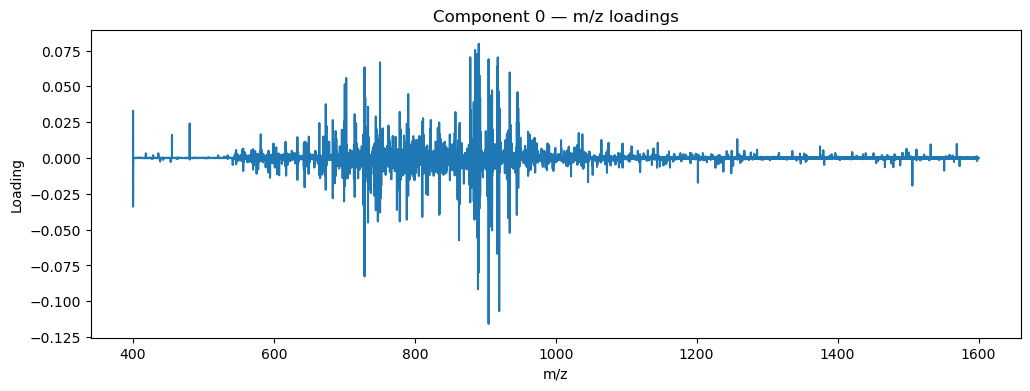

In [22]:
mz_axis = store["mz_axis"][:]  # shape (n_mz_bins,)

# For a given component, find the m/z values with highest loading
component_idx = 0  # first (most important) component

data = []
for idx in range(0, 100):
    loadings = Vt[idx, :]  # shape (n_mz_bins,)
    
    # Top 20 m/z values driving this component
    top_idx = np.argsort(np.abs(loadings))[::-1][:25]
    top_mz  = mz_axis[top_idx]
    top_loadings = loadings[top_idx]
    mzdata = []
    for pair in range(0, 25):
        mzdata.append(top_mz[pair])
        mzdata.append(top_loadings[pair])
    data.append(mzdata)
    
# Plot the full loading spectrum for a component
plt.figure(figsize=(12, 4))
plt.plot(mz_axis, loadings)
plt.xlabel("m/z")
plt.ylabel("Loading")
plt.title(f"Component {component_idx} — m/z loadings")
plt.show()

In [23]:
import pandas as pd
column_list = [f"{prefix}{i}" for i in range(1, 26) for prefix in ("mz", "loading")]
pd.DataFrame(data, columns = column_list)

,mz1,loading1,mz2,loading2,mz3,loading3,mz4,loading4,mz5,loading5,...,mz21,loading21,mz22,loading22,mz23,loading23,mz24,loading24,mz25,loading25
0,888.621582,0.149903,888.626245,0.148203,888.640236,0.144352,888.630909,0.143998,888.644900,0.143645,...,890.665425,0.101581,906.624859,0.100365,890.623405,0.098150,906.638991,0.095078,888.607591,0.093917
1,888.649564,0.187200,888.654227,0.172974,888.644900,0.167047,888.616918,-0.155570,888.612254,-0.152547,...,889.652543,0.101023,904.605123,-0.097748,916.681537,0.096407,906.615438,-0.096217,889.657209,0.094601
2,888.630909,-0.196859,888.635573,-0.175190,888.626245,-0.161491,890.646750,-0.156427,890.642081,-0.149750,...,888.612254,0.101239,888.663555,0.101158,888.598264,0.100772,890.670094,0.100412,906.638991,-0.100129
3,888.640236,0.167535,888.621582,-0.163993,888.616918,-0.145031,888.658891,-0.139850,890.632743,-0.138932,...,888.654227,-0.096343,888.668218,-0.092855,889.643210,0.092338,904.633355,0.092189,890.628074,-0.091663
4,885.518318,0.150505,885.513662,0.142255,888.612254,-0.135742,885.522973,0.134528,888.644900,-0.131942,...,885.527629,0.094615,888.658891,0.090823,888.640236,-0.085385,890.660757,-0.085024,885.504352,0.084944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,700.525162,-0.163456,700.521021,-0.158216,700.529303,-0.124892,700.516881,-0.111938,728.559644,0.105437,...,744.549399,-0.071899,728.593426,0.071800,744.545130,-0.070255,904.652177,0.069488,892.604110,0.069280
96,892.632155,0.125650,892.636829,0.125008,904.619239,0.120323,892.627481,0.116957,892.641503,0.111365,...,890.604730,-0.073571,885.546251,0.072716,904.656883,0.071991,714.565653,0.071258,728.546975,0.069084
97,932.680229,-0.103886,917.652816,-0.101139,885.555562,0.098274,917.676512,0.098237,917.681251,0.096848,...,890.614067,0.070787,892.655526,-0.070716,728.551198,0.070110,917.662294,-0.070048,944.696746,0.069655
98,919.696547,-0.111439,906.657834,-0.104161,919.691803,-0.103235,919.701292,-0.101996,907.666208,0.093021,...,889.661875,0.071711,905.612355,0.071700,918.700478,0.071366,862.623621,-0.071234,907.670922,0.071141
